In [2]:
%load_ext cython

In [3]:
%%cython

# =========================================================================
# PART 1: C LIBRARY IMPORTS AND GLOBAL DEFINITIONS
# =========================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Import Python libraries needed for the LLM part
import time
import json
import ollama
import numpy as np
import hashlib
from collections import defaultdict
import threading  # <-- ADD THIS LINE


# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

# Data structures (MODIFIED to track more info)
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    # V13: Added fields for tracking agent intervention
    int age
    int improvement_count
    int llm_enhanced
    int last_improvement_iteration

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Global variables for the problem instance (RENAMED to avoid name collision)
cdef int nf = 2
cdef double *capacities = NULL
cdef int **g_weights = NULL  # RENAMED from 'weights'
cdef int **g_profits = NULL  # RENAMED from 'profits'
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# =========================================================================
# PART 2: CORE CYTHON HELPER FUNCTIONS (Unchanged, but with renamed vars)
# =========================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    # V13: Initialize new tracking fields
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.last_improvement_iteration = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    # V13: Copy new tracking fields
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    p_ind.last_improvement_iteration = i.last_improvement_iteration
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, g_weights, g_profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if g_weights != NULL:
        for i in range(nf):
            if g_weights[i] != NULL:
                free(g_weights[i])
        free(g_weights)
        g_weights = NULL
    if g_profits != NULL:
        for i in range(nf):
            if g_profits[i] != NULL:
                free(g_profits[i])
        free(g_profits)
        g_profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# =========================================================================
# PART 3: PROBLEM LOADING AND EVALUATION FUNCTIONS (Unchanged, but with renamed vars)
# =========================================================================

def loadMOKP(char *filename):
    global nf, ni, capacities, g_weights, g_profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        g_weights = <int **>chk_malloc(nf * sizeof(void*))
        g_profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            g_weights[f] = <int *>chk_malloc(ni * sizeof(int))
            g_profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                g_weights[f][i] = int(source.readline().strip())
                g_profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + g_weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += g_weights[k][x.d[j]]
                x.f[k] += g_profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# =========================================================================
# PART 4: MODULAR LOCAL SEARCH & EVALUATION HELPERS (Unchanged, but with renamed vars)
# =========================================================================

cdef void original_swap_heuristic(pop *SP, pop *Sarchive, int size, int L_val, double kappa_val):
    """The original logic from Indicator_local_search1, now modular."""
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L_val * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L_val):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= g_weights[r][mino]
                        x.f[r] -= g_profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L_val:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + g_weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += g_weights[r][maxp]
                                        x.f[r] += g_profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += g_weights[r][mino]
                            x.f[r] += g_profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= g_weights[t][remplace[r]]
                                    x.f[t] -= g_profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[tv]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

cdef void adaptive_local_search(pop *SP, pop *Sarchive, int size, str heuristic_name, int L_val, double kappa_val):
    """Dispatches to the correct local search heuristic."""
    if heuristic_name == "original_swap":
        original_swap_heuristic(SP, Sarchive, size, L_val, kappa_val)
    else:
        # Fallback to original
        original_swap_heuristic(SP, Sarchive, size, L_val, kappa_val)

cdef dict extract_solution_data_for_python(ind *solution_ind):
    cdef int i
    data = {
        'f': [solution_ind.f[i] for i in range(nf)],
        'capa': [solution_ind.capa[i] for i in range(nf)],
        'nombr': solution_ind.nombr,
        'Items': [solution_ind.Items[i] for i in range(ni)]
    }
    return data

def extract_problem_features_for_llm():
    if capacities == NULL or g_weights == NULL or g_profits == NULL:
        return None
    total_capacity = sum(capacities[i] for i in range(nf))
    total_avg_weight = sum(sum(g_weights[obj][i] for i in range(ni)) for obj in range(nf)) / nf
    capacity_tightness = total_avg_weight / total_capacity if total_capacity > 0 else 0
    profit_variances = []
    weight_variances = []
    for obj in range(nf):
        profits_list = [g_profits[obj][i] for i in range(ni)]
        weights_list = [g_weights[obj][i] for i in range(ni)]
        profit_variances.append(np.var(profits_list))
        weight_variances.append(np.var(weights_list))
    features = {
        "num_items": ni, "num_objectives": nf, "capacity_tightness": round(capacity_tightness, 4),
        "avg_profit_variance": round(np.mean(profit_variances), 2),
        "avg_weight_variance": round(np.mean(weight_variances), 2),
    }
    return features

# =========================================================================
# PART 5: THE LLM CRITIC-AUTHOR AGENT (V17 - ROBUST VALIDATION)
# =========================================================================

class CriticAuthorAgent:
    """
    V17: The Critic-Author Agent with robust validation for creative solution generation.
    """
    def __init__(self, model_name="llama3:latest"):
        self.model_name = model_name
        self.cache = {}



    def _call_llm(self, prompt, cache_key, timeout_seconds=70):
        if cache_key in self.cache:
            print(f"  [LLM Cache Hit] Using cached response.")
            return self.cache[cache_key]
        print(f"  [LLM Agent Call] Requesting a creative refinement (timeout: {timeout_seconds}s)...")
        
        result_container = {}
        exception_container = {}

        def target():
            try:
                response = ollama.generate(model=self.model_name, prompt=prompt, format='json')
                response_text = response.get('response', '').strip()
                if not response_text:
                    raise ValueError("Empty response from LLM")
                result_container['result'] = json.loads(response_text)
            except Exception as e:
                exception_container['exception'] = e

        thread = threading.Thread(target=target)
        thread.daemon = True
        thread.start()
        thread.join(timeout_seconds)

        if thread.is_alive():
            print(f"  [LLM Error] Request timed out after {timeout_seconds} seconds.")
            return None

        if 'exception' in exception_container:
            e = exception_container['exception']
            print(f"  [LLM Error] {e}.")
            return None

        if 'result' in result_container:
            result = result_container['result']
            self.cache[cache_key] = result
            print(f"  [LLM Agent Success] Received a new solution.")
            return result
        
        return None # Should not be reached if logic is correct

    def generate_refined_solution_v3(self, solution_data, problem_data):
        """
        V17: Asks the LLM to generate a new solution with robust validation.
        """
        cache_key = f"gen_v17_{hash(str(solution_data['Items']) + str(problem_data))}"
        
        num_items_to_change = 5 

        prompt = f"""
You are an expert optimizer for a multi-objective knapsack problem. You are given a current solution that has stagnated.

PROBLEM DATA:
- Number of items: {problem_data['num_items']}
- Number of objectives: {problem_data['num_objectives']}

CURRENT SOLUTION (as a binary list of 0s and 1s, where 1 means the item is selected):
{solution_data['Items']}

CURRENT OBJECTIVE VALUES:
- Objective 1 Profit: {solution_data['f'][0]}
- Objective 2 Profit: {solution_data['f'][1]}

YOUR TASK:
The current solution is stuck. Your goal is to generate a NEW, IMPROVED solution.
1. Analyze the current solution.
2. Identify up to {num_items_to_change} items to change (remove some, add some).
3. Generate a new binary list for the solution that you believe will be better.
4. Your new solution MUST be a valid binary list of length {problem_data['num_items']}, containing ONLY 0s and 1s.

Respond ONLY with a JSON object containing the new solution under the key 'new_items'.
Example: {{"new_items": [1, 0, 0, 1, 0, 1]}}
"""
        result = self._call_llm(prompt, cache_key)
        
        if result and 'new_items' in result:
            llm_items = result['new_items']
            
            # --- V17: ROBUST VALIDATION ---
            is_valid = True
            error_message = ""
            
            if not isinstance(llm_items, list):
                is_valid = False
                error_message = "Response is not a list."
            elif len(llm_items) != problem_data['num_items']:
                is_valid = False
                error_message = f"List has incorrect length: {len(llm_items)} instead of {problem_data['num_items']}."
            else:
                for i, item in enumerate(llm_items):
                    if item not in [0, 1]:
                        is_valid = False
                        error_message = f"List contains invalid value '{item}' at index {i}. Only 0 and 1 are allowed."
                        break
            
            if is_valid:
                result['state'] = {
                    'Items': llm_items,
                }
                print(f"  [LLM Validation] Passed. Solution is valid.")
                return result
            else:
                print(f"  [LLM Validation] Failed! {error_message}")
                print(f"  [LLM Debug] Received: {llm_items}")
                return None # Return None to indicate failure
        else:
            print("  [LLM Validation] Failed! 'new_items' key not found in response.")
            return None

cdef bint evaluate_and_add_llm_solution(pop *P, int *llm_items_array):
    """
    V16: Evaluates a completely new solution generated by the LLM and adds it to the population.
    Returns True on success, False on failure.
    """
    if P == NULL or P.size == 0:
        return False

    cdef ind *new_solution = create_ind(nf)
    cdef int i, j, faisable
    cdef int sol_idx

    for i in range(ni):
        new_solution.Items[i] = llm_items_array[i]

    new_solution.nombr = 0
    new_solution.nombr_nonpris = 0
    for j in range(nf):
        new_solution.capa[j] = 0.0
        new_solution.f[j] = 0.0
    
    random_init_ind(new_solution)

    for j in range(ni):
        faisable = 1
        l = 0
        while l < nf and faisable == 1:
            if new_solution.capa[l] + g_weights[l][new_solution.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        
        if faisable == 1 and new_solution.Items[new_solution.d[j]] == 1:
            for k in range(nf):
                new_solution.capa[k] += g_weights[k][new_solution.d[j]]
                new_solution.f[k] += g_profits[k][new_solution.d[j]]
            new_solution.nombr += 1
        else:
            pass
    
    calcul_weight(P, P.size)
    sol_idx = compute_fitness_and_select(P, new_solution, P.size)
    
    free_ind(new_solution)

    if sol_idx != -1:
        print(f"  [Agent Success] LLM-generated solution was good enough to join the population.")
        return True
    else:
        print(f"  [Agent Fail] LLM-generated solution was not good enough to join the population.")
        return False

# =========================================================================
# PART 6: MAIN EXECUTION FUNCTION (V17 - FINAL)
# =========================================================================
def load_baseline_pareto_front(filename):
    """A pure Python function to load the baseline data."""
    baseline_pareto_front = []
    try:
        with open(filename, "r") as f:
            for line in f:
                if line.strip() and not line.startswith("#"):
                    baseline_pareto_front.append([float(x) for x in line.split()])
    except FileNotFoundError:
        print(f"Warning: Baseline file {filename} not found. Dominance will be 0%.")
    return baseline_pareto_front

def run_critic_author_moacp_v17(instance_file, weights_file, nbitems, num_objectives, output_file_base, baseline_pareto_front):
    """
    V17: The "Critic-Author Agent" with robust validation for creative solution generation.
    """
    cdef int i, j
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef ind *x
    cdef int it
    cdef int *llm_items_c_array

    NBL = 150
    NRUNS = 10
    METRIC_INTERVAL = 10
    STAGNATION_WINDOW = 5
    HV_IMPROVEMENT_THRESHOLD = 100.0
    TIME_BUDGET_SECONDS = 600

    total_time = 0
    start_time = time.time()

    for run in range(1, NRUNS + 1):
        print(f"\n--- RUN {run}/{NRUNS} --- V17 Critic-Author Agent (Robust)")
        print(f"Instance: {instance_file.decode()}, Items: {nbitems}, Objectives: {num_objectives}")

        global nf, ni, NBITEMS, alpha, paretoIni, L, kappa, nombreLIGNE, nextLn, inv, vector_weight
        global capacities, g_weights, g_profits, OBJ_Weights
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        alpha = 10
        paretoIni = 28000
        L = 5
        kappa = 0.05
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        agent = CriticAuthorAgent()
        problem_features = extract_problem_features_for_llm()
        print(f"  [Problem Features] {json.dumps(problem_features, indent=4)}")

        run_log = {"iterations": [], "hypervolumes": [], "dominance_percentages": []}
        last_hv = 0.0
        stagnation_counter = 0

        P = create_pop(paretoIni, nf)
        it = 0
        while it < NBL and (time.time() - start_time) < TIME_BUDGET_SECONDS:
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            adaptive_local_search(solutions, archive, alpha, "original_swap", L, kappa)
            
            extractPtoArchive(archive, P)
            complete_free_pop(solutions)
            complete_free_pop(archive)

            if it % METRIC_INTERVAL == 0:
                current_pareto = []
                for i in range(P.size):
                    current_pareto.append([P.ind_array[i].f[0], P.ind_array[i].f[1]])
                
                current_hv = calculate_hypervolume(current_pareto)
                dominance = calculate_dominance_percentage(current_pareto, baseline_pareto_front)
                
                run_log["iterations"].append(it)
                run_log["hypervolumes"].append(current_hv)
                run_log["dominance_percentages"].append(dominance)
                
                print(f"  [Metrics] Iter {it:3d}: HV={current_hv:10.2f}, Dominates Baseline={dominance:5.2f}%")

                hv_change = current_hv - last_hv
                if hv_change < HV_IMPROVEMENT_THRESHOLD:
                    stagnation_counter += 1
                    print(f"  [Stagnation] Counter: {stagnation_counter}/{STAGNATION_WINDOW}")
                else:
                    stagnation_counter = 0

                last_hv = current_hv

                # --- THE CRITIC-AUTHOR INTERVENTION (V17 - FINAL) ---
                if stagnation_counter >= STAGNATION_WINDOW:
                    print("\n!!! STAGNATION DETECTED. Calling Critic-Author Agent (V17) for creative refinement. !!!")

                    agent_response = agent.generate_refined_solution_v3(extract_solution_data_for_python(P.ind_array[0]), problem_features)
                    
                    if agent_response and 'state' in agent_response and agent_response['state'] is not None:
                        llm_items_list = agent_response['state'].get('Items')
                        
                        if llm_items_list and len(llm_items_list) == ni:
                            llm_items_c_array = <int *>chk_malloc(ni * sizeof(int))
                            for i in range(ni):
                                llm_items_c_array[i] = llm_items_list[i]
                                
                            success = evaluate_and_add_llm_solution(P, llm_items_c_array)
                            
                            free(llm_items_c_array)

                            if success:
                                stagnation_counter = 0
                                L = 8
                                kappa = 0.08
                            else:
                                pass
                        else:
                            print("  [Agent Fail] Received invalid solution after validation check.")
                    else:
                        print("  [Agent Fail] Could not get a valid solution from LLM.")
                    
                    if stagnation_counter >= STAGNATION_WINDOW:
                        print("  [Fallback] Applying random parameter reset.")
                        L = 15
                        kappa = 0.2
                        stagnation_counter = 0

            it += 1

        with open(f"{output_file_base}_V17_pareto.txt", "a") as f:
            f.write(f"\n# RUN {run}\n")
            for i in range(P.size):
                for j in range(nf):
                    f.write(f"{P.ind_array[i].f[j]:.6f} ")
                f.write("\n")
        
        with open(f"{output_file_base}_V17_log.json", "w") as f:
            json.dump(run_log, f, indent=2)

        complete_free_pop(P)
        cleanup_globals()

    total_time = time.time() - start_time
    print(f"\nTotal execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")
    with open(f"{output_file_base}_V17_pareto.txt", "a") as f:
        f.write(f"# RUNTIME: {total_time:.2f}\n")

# Python helper functions for metrics (Unchanged)
def calculate_hypervolume(pareto_points, ref_point=None):
    if not pareto_points: return 0.0
    if ref_point is None:
        max_f1 = max(p[0] for p in pareto_points)
        max_f2 = max(p[1] for p in pareto_points)
        ref_point = (max_f1 * 1.1, max_f2 * 1.1)
    points = sorted(pareto_points, key=lambda p: p[0])
    hv = 0.0
    for i in range(len(points) - 1):
        x1, y1 = points[i]
        x2, y2 = points[i + 1]
        hv += (x2 - x1) * (ref_point[1] - y1)
    if points:
        x_last, y_last = points[-1]
        hv += (ref_point[0] - x_last) * (ref_point[1] - y_last)
    return hv

def calculate_dominance_percentage(new_pareto, reference_pareto):
    if not reference_pareto: return 100.0
    if not new_pareto: return 0.0
    dominated_count = 0
    for ref_point in reference_pareto:
        is_dominated = any(new_p[0] >= ref_point[0] and new_p[1] >= ref_point[1] and (new_p[0] > ref_point[0] or new_p[1] > ref_point[1]) for new_p in new_pareto)
        if is_dominated: dominated_count += 1
    return (dominated_count / len(reference_pareto)) * 100

In [4]:
# Cell 2
!copy 2502_ResultsMD.txt 2502_ResultsMD_baseline.txt
baseline_data = load_baseline_pareto_front("2502_ResultsMD_baseline.txt")

# Use the V17 function
run_critic_author_moacp_v17(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_ResultsMD", baseline_data)

        1 fichier(s) copi‚(s).

--- RUN 1/10 --- V17 Critic-Author Agent (Robust)
Instance: 250.2.txt, Items: 250, Objectives: 2
  [Problem Features] {
    "num_items": 250,
    "num_objectives": 2,
    "capacity_tightness": 1.0,
    "avg_profit_variance": 745.59,
    "avg_weight_variance": 693.31
}
  [Metrics] Iter   0: HV= 927946.72, Dominates Baseline= 0.28%
  [Metrics] Iter  10: HV=1250476.69, Dominates Baseline= 7.36%
  [Metrics] Iter  20: HV=3431437.82, Dominates Baseline=11.54%
  [Metrics] Iter  30: HV=4719855.45, Dominates Baseline=24.13%
  [Metrics] Iter  40: HV=5179601.92, Dominates Baseline=29.44%
  [Metrics] Iter  50: HV=6018937.88, Dominates Baseline=31.14%
  [Metrics] Iter  60: HV=6015402.88, Dominates Baseline=31.14%
  [Stagnation] Counter: 1/5
  [Metrics] Iter  70: HV=6008069.88, Dominates Baseline=32.91%
  [Stagnation] Counter: 2/5
  [Metrics] Iter  80: HV=6002310.88, Dominates Baseline=37.79%
  [Stagnation] Counter: 3/5
  [Metrics] Iter  90: HV=5998982.88, Dominates B

Loading data and calculating Pareto fronts...
Baseline points loaded: 1413
V17 points loaded: 3990
Calculating true Pareto fronts...
Baseline Pareto front size: 212
V17 Pareto front size: 579


ValueError: operands could not be broadcast together with shapes (212,) (579,) 

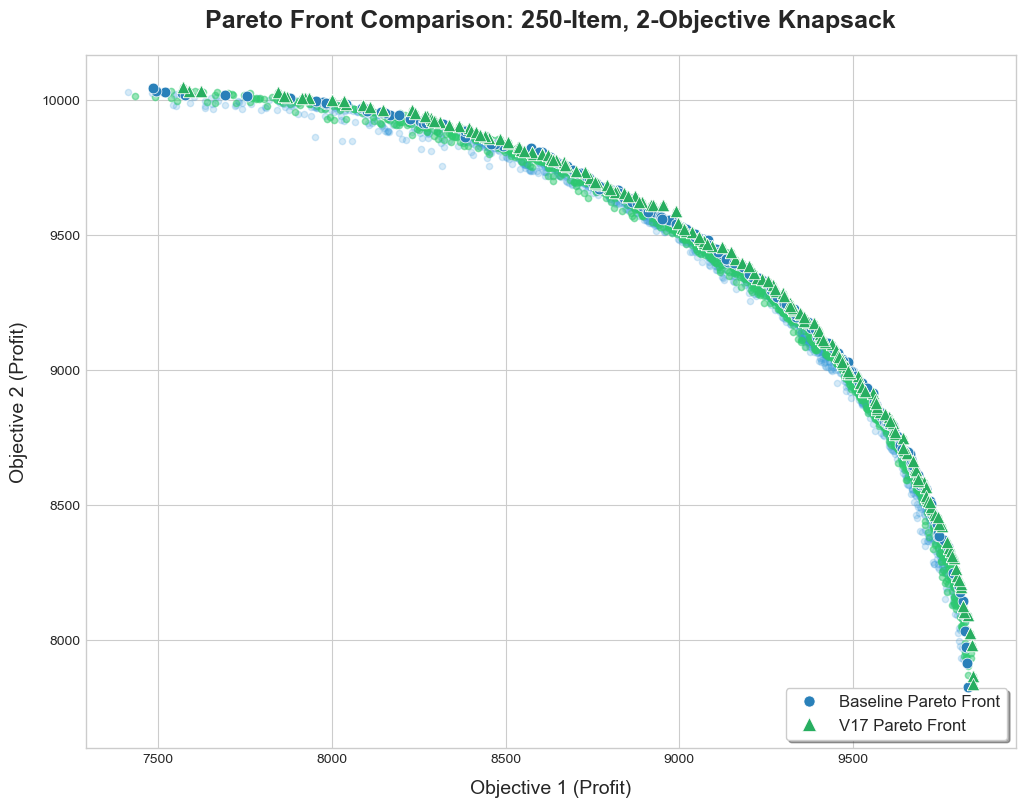

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def get_true_pareto_front_fast(points):
    """
    Efficiently calculates the true Pareto front using NumPy.
    This is much faster for large datasets.
    """
    if not points:
        return np.array([]).reshape(0, 2)
    
    points_np = np.array(points)
    is_dominated = np.zeros(len(points_np), dtype=bool)
    
    for i in range(len(points_np)):
        if not is_dominated[i]:
            for j in range(len(points_np)):
                if i != j:
                    # Check if point j dominates point i
                    if np.all(points_np[j] >= points_np[i]) and np.any(points_np[j] > points_np[i]):
                        is_dominated[i] = True
                        break # No need to check other points against i anymore
    return points_np[~is_dominated]

def load_pareto_front_from_file(filename):
    """Loads Pareto points from a text file, ignoring comments."""
    points = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#"):
                    parts = line.split()
                    if len(parts) >= 2:
                        try:
                            points.append([float(parts[0]), float(parts[1])])
                        except ValueError:
                            print(f"Warning: Could not parse line in {filename}: '{line}'. Skipping.")
    except FileNotFoundError:
        print(f"Warning: File not found {filename}. Returning empty list.")
    return points

def plot_pareto_comparison_clean(baseline_file, v17_file, problem_name="Multi-Objective Knapsack"):
    """
    Creates a clean, professional visualization comparing Pareto fronts.
    """
    print("Loading data and calculating Pareto fronts...")
    
    # Load data from files
    baseline_points = load_pareto_front_from_file(baseline_file)
    v17_points = load_pareto_front_from_file(v17_file)
    
    print(f"Baseline points loaded: {len(baseline_points)}")
    print(f"V17 points loaded: {len(v17_points)}")

    # --- Robust Error Handling ---
    if not baseline_points and not v17_points:
        print("Error: Both baseline and V17 result files are empty or could not be read. Cannot generate plot.")
        return

    print("Calculating true Pareto fronts...")
    # Calculate the true Pareto fronts using the fast method
    baseline_pareto = get_true_pareto_front_fast(baseline_points)
    v17_pareto = get_true_pareto_front_fast(v17_points)
    
    print(f"Baseline Pareto front size: {len(baseline_pareto)}")
    print(f"V17 Pareto front size: {len(v17_pareto)}")

    # --- Set up the plot style ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 9))
    
    # Define colors
    color_baseline = '#3498db'
    color_v17 = '#2ecc71'
    color_baseline_pareto = '#2980b9'
    color_v17_pareto = '#27ae60'

    # --- Plot the full sets of points (background) ---
    if baseline_points:
        baseline_np = np.array(baseline_points)
        ax.scatter(baseline_np[:, 0], baseline_np[:, 1], c=color_baseline, alpha=0.2, s=20, label='Baseline Solutions')
    if v17_points:
        v17_np = np.array(v17_points)
        ax.scatter(v17_np[:, 0], v17_np[:, 1], c=color_v17, alpha=0.2, s=20, label='V17 Solutions')

    # --- Plot the true Pareto fronts (foreground) ---
    if len(baseline_pareto) > 0:
        ax.scatter(baseline_pareto[:, 0], baseline_pareto[:, 1], 
                   c=color_baseline_pareto, marker='o', s=60, 
                   label='Baseline Pareto Front', edgecolors='white', linewidth=0.5, zorder=10)
    if len(v17_pareto) > 0:
        ax.scatter(v17_pareto[:, 0], v17_pareto[:, 1], 
                   c=color_v17_pareto, marker='^', s=80, 
                   label='V17 Pareto Front', edgecolors='white', linewidth=0.5, zorder=10)

    # --- Formatting and Annotations ---
    ax.set_title(f'Pareto Front Comparison: {problem_name}', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Objective 1 (Profit)', fontsize=14, labelpad=10)
    ax.set_ylabel('Objective 2 (Profit)', fontsize=14, labelpad=10)
    
    legend_elements = []
    if len(baseline_pareto) > 0:
        legend_elements.append(plt.Line2D([0], [0], marker='o', color=color_baseline_pareto, markersize=8, label='Baseline Pareto Front', linestyle='None', markeredgecolor='white', markeredgewidth=0.5))
    if len(v17_pareto) > 0:
        legend_elements.append(plt.Line2D([0], [0], marker='^', color=color_v17_pareto, markersize=10, label='V17 Pareto Front', linestyle='None', markeredgecolor='white', markeredgewidth=0.5))
    
    ax.legend(handles=legend_elements, loc='lower right', fontsize=12, frameon=True, fancybox=True, shadow=True)
    
    info_text = ""
    if len(v17_pareto) > 0 and len(baseline_pareto) > 0:
        # Vectorized dominance check for speed
        v17_pareto_np = np.array(v17_pareto)
        baseline_pareto_np = np.array(baseline_pareto)
        
        # Check for each V17 point if it dominates any baseline point
        is_dominated = np.zeros(len(v17_pareto_np), dtype=bool)
        for i, v17_point in enumerate(v17_pareto_np):
            if np.any((baseline_pareto_np[:, 0] >= v17_point[0]) & (baseline_pareto_np[:, 1] >= v17_point[1]) & 
                      ((baseline_pareto_np[:, 0] > v17_point[0]) | (baseline_pareto_np[:, 1] > v17_point[1]))):
                is_dominated[i] = True
        # A V17 point dominates a baseline point if it is not dominated by any baseline point
        # We need to check if any V17 point is NOT dominated by any baseline point
        is_v17_not_dominated = ~np.any((baseline_pareto_np[:, 0] >= v17_pareto_np[:, 0]) & (baseline_pareto_np[:, 1] >= v17_pareto_np[:, 1]), axis=1)
        
        # A V17 point dominates a baseline point if it's not dominated by any baseline point
        # AND it is better in at least one objective
        is_v17_dominant = is_v17_not_dominated & (np.any(v17_pareto_np[:, 0] > baseline_pareto_np[:, 0]) | np.any(v17_pareto_np[:, 1] > baseline_pareto_np[:, 1]))
        
        dominated_count = np.sum(is_v17_dominant)
        dominance_percentage = (dominated_count / len(baseline_pareto)) * 100
        info_text += f'V17 Dominates Baseline: {dominance_percentage:.2f}%\n'
    
    info_text += f'Baseline Pareto Size: {len(baseline_pareto)}\n'
    info_text += f'V17 Pareto Site: {len(v17_pareto)}'

    ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    plt.tight_layout()
    print("Displaying plot...")
    plt.show()


# --- HOW TO USE ---
# Make sure you have the result files in the same directory
# The baseline file you created earlier
baseline_file = "2502_ResultsMD_baseline.txt" 
# The output file from your V17 run
v17_file = "2502_ResultsMD_V17_pareto.txt"

# Generate the plot
plot_pareto_comparison_clean(baseline_file, v17_file, problem_name="250-Item, 2-Objective Knapsack")